In [9]:
import pyzx as zx
import random
import matplotlib.pyplot as plt
from fractions import Fraction
import numpy as np


def chsh_game(strategy):
    # Definimos el juego CHSH. La función strategy es la estrategia de Alice y Bob, que toma como entrada sus bits x e y, y devuelve sus respuestas a y b respectivamente.
    x, y = random.randint(0, 1), random.randint(0, 1)
    a, b = strategy(x, y)
    
    if (a != b) == (x & y):
        return 1
    return 0


# -Ahora construimos el circuito para la estrategia cuántica óptima. Alice y Bob comparten un e-bit, y luego aplican rotaciones Ry dependiendo de sus bits de entrada x e y. Finalmente, miden sus qubits para obtener sus respuestas a y b.
def chsh_circuit(x, y):
    c = zx.Circuit(2)
    
    c.add_gate("H", 0)
    c.add_gate("CNOT", 0, 1)
    

    def add_ry(circ, qubit, phase_fraction):
        # 1/2 en lugar de 0.5
        circ.add_gate("XPhase", qubit, phase=Fraction(1, 2))
        circ.add_gate("ZPhase", qubit, phase=phase_fraction)
        # -1/2 en lugar de -0.5
        circ.add_gate("XPhase", qubit, phase=Fraction(-1, 2))

    # Acciones de Alice
    if x == 1:
 
        add_ry(c, 0, Fraction(-1, 2))
        
    # Acciones de Bob
    if y == 0:
        add_ry(c, 1, Fraction(-1, 4))
    else:
        add_ry(c, 1, Fraction(1, 4))
        
    return c

(x,y) = (0,0)


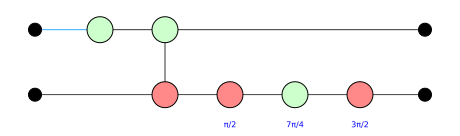

(x,y) = (0,1)


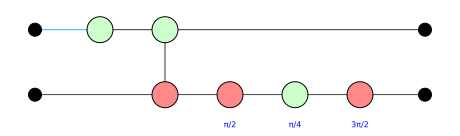

(x,y) = (1,0)


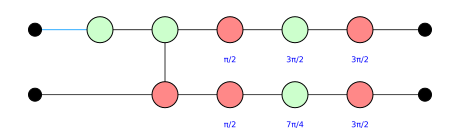

(x,y) = (1,1)


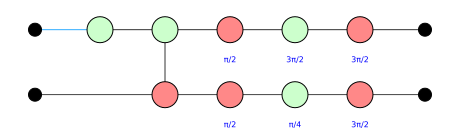

In [10]:
# Dibujar los cuatro circuitos posibles

print("(x,y) = (0,0)")
fig = zx.draw_matplotlib(chsh_circuit(0, 0))
display(fig)
plt.close(fig)

print("(x,y) = (0,1)")
fig = zx.draw_matplotlib(chsh_circuit(0, 1))
display(fig)
plt.close(fig)

print("(x,y) = (1,0)")
fig = zx.draw_matplotlib(chsh_circuit(1, 0))
display(fig)
plt.close(fig)

print("(x,y) = (1,1)")
fig = zx.draw_matplotlib(chsh_circuit(1, 1))
display(fig)
plt.close(fig)

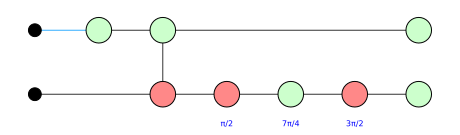

In [4]:
chsh00 = chsh_circuit(0, 0).to_graph()
chsh01 = chsh_circuit(0, 1).to_graph()  
chsh10 = chsh_circuit(1, 0).to_graph()
chsh11 = chsh_circuit(1, 1).to_graph()

salida_0 = chsh00.outputs()[0]
salida_1 = chsh00.outputs()[1]


chsh00.set_type(salida_0, zx.VertexType.Z)
chsh00.set_type(salida_1, zx.VertexType.Z)

zx.draw_matplotlib(chsh00)

Evaluando rama de medida: m0=0, m1=0. Variables clásicas (x,y)=(0, 0)
i1


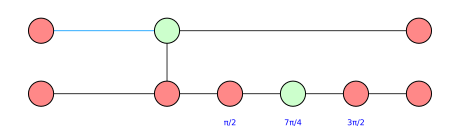

i2


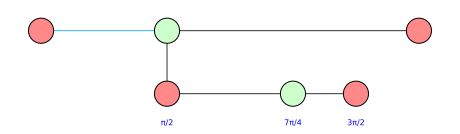

i8


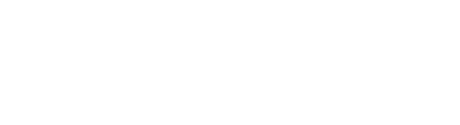

Rama m=(0,0) (x,y)=(0,0) -> Amplitud: 2.414-1.000j, Probabilidad: 6.828
Evaluando rama de medida: m0=0, m1=1. Variables clásicas (x,y)=(0, 0)
i1


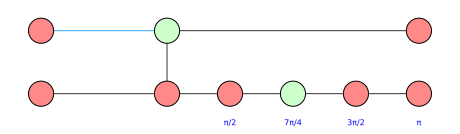

i2


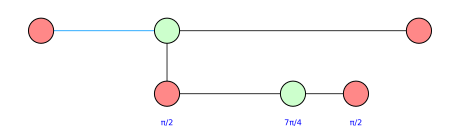

i8


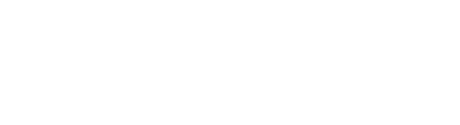

Rama m=(0,1) (x,y)=(0,0) -> Amplitud: -1.000+0.414j, Probabilidad: 1.172
Evaluando rama de medida: m0=1, m1=0. Variables clásicas (x,y)=(0, 0)
i1


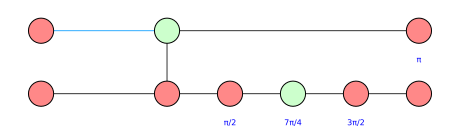

i2


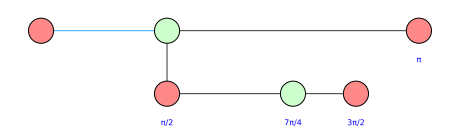

i8


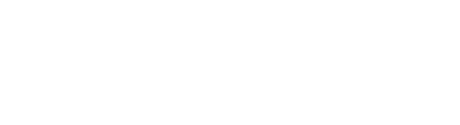

Rama m=(1,0) (x,y)=(0,0) -> Amplitud: 1.000-0.414j, Probabilidad: 1.172
Evaluando rama de medida: m0=1, m1=1. Variables clásicas (x,y)=(0, 0)
i1


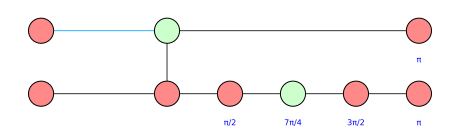

i2


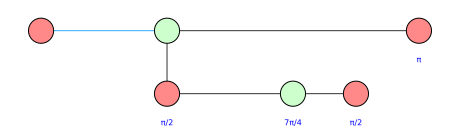

i8


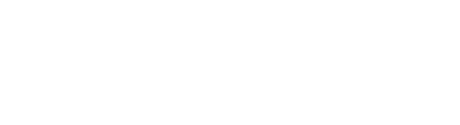

Rama m=(1,1) (x,y)=(0,0) -> Amplitud: 2.414-1.000j, Probabilidad: 6.828
Evaluando rama de medida: m0=0, m1=0. Variables clásicas (x,y)=(0, 1)
i1


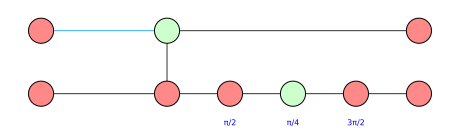

i2


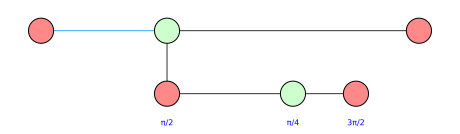

i8


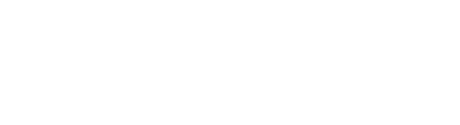

Rama m=(0,0) (x,y)=(0,1) -> Amplitud: 2.414+1.000j, Probabilidad: 6.828
Evaluando rama de medida: m0=0, m1=1. Variables clásicas (x,y)=(0, 1)
i1


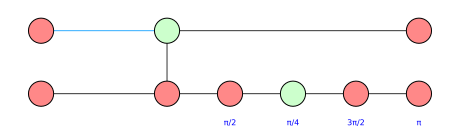

i2


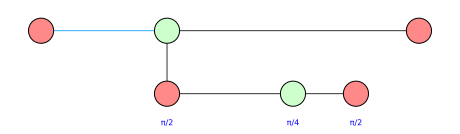

i8


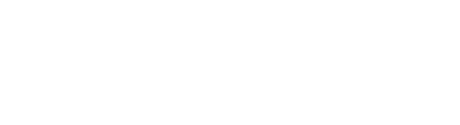

Rama m=(0,1) (x,y)=(0,1) -> Amplitud: 1.000+0.414j, Probabilidad: 1.172
Evaluando rama de medida: m0=1, m1=0. Variables clásicas (x,y)=(0, 1)
i1


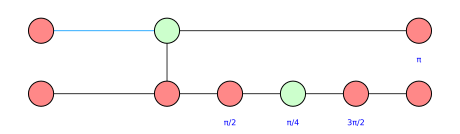

i2


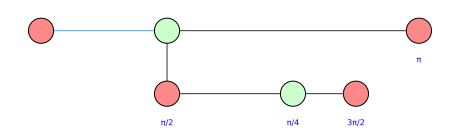

i8


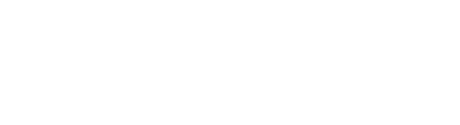

Rama m=(1,0) (x,y)=(0,1) -> Amplitud: -1.000-0.414j, Probabilidad: 1.172
Evaluando rama de medida: m0=1, m1=1. Variables clásicas (x,y)=(0, 1)
i1


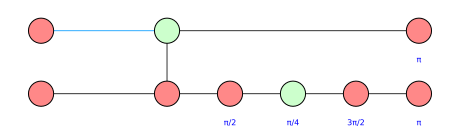

i2


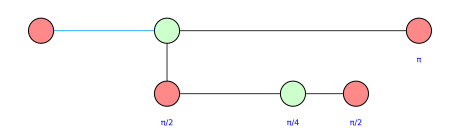

i8


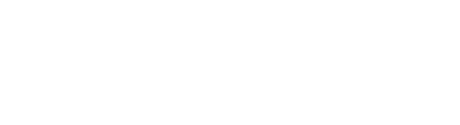

Rama m=(1,1) (x,y)=(0,1) -> Amplitud: 2.414+1.000j, Probabilidad: 6.828
Evaluando rama de medida: m0=0, m1=0. Variables clásicas (x,y)=(1, 0)
i1


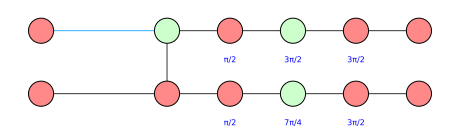

i2


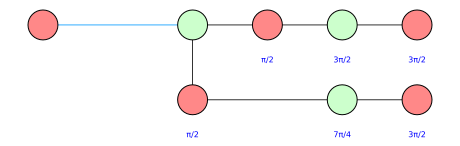

i8


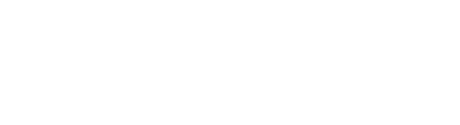

Rama m=(0,0) (x,y)=(1,0) -> Amplitud: 1.000-2.414j, Probabilidad: 6.828
Evaluando rama de medida: m0=0, m1=1. Variables clásicas (x,y)=(1, 0)
i1


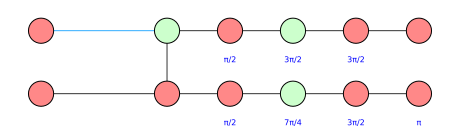

i2


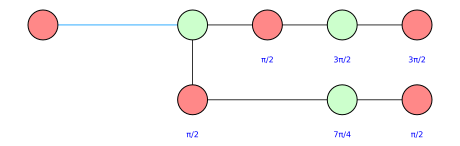

i8


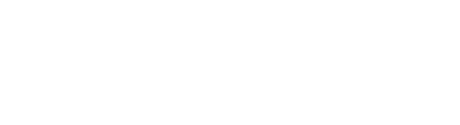

Rama m=(0,1) (x,y)=(1,0) -> Amplitud: 0.414-1.000j, Probabilidad: 1.172
Evaluando rama de medida: m0=1, m1=0. Variables clásicas (x,y)=(1, 0)
i1


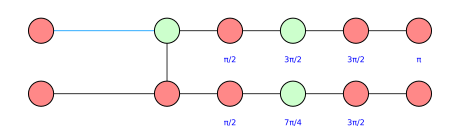

i2


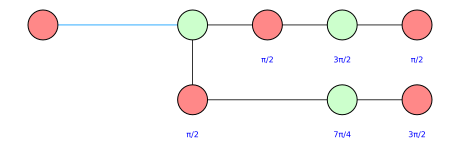

i8


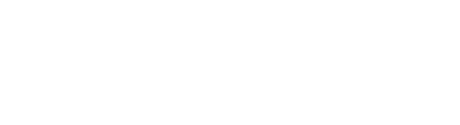

Rama m=(1,0) (x,y)=(1,0) -> Amplitud: -0.414+1.000j, Probabilidad: 1.172
Evaluando rama de medida: m0=1, m1=1. Variables clásicas (x,y)=(1, 0)
i1


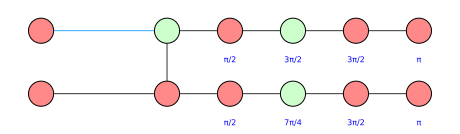

i2


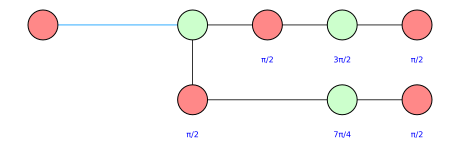

i8


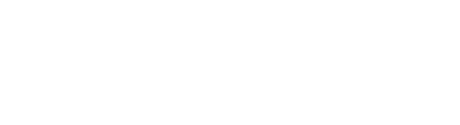

Rama m=(1,1) (x,y)=(1,0) -> Amplitud: 1.000-2.414j, Probabilidad: 6.828
Evaluando rama de medida: m0=0, m1=0. Variables clásicas (x,y)=(1, 1)
i1


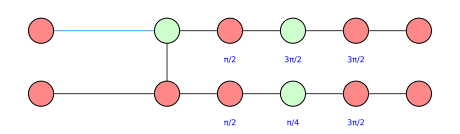

i2


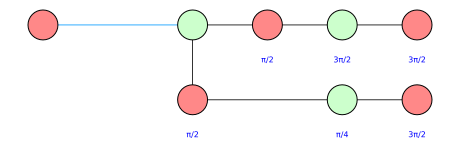

i8


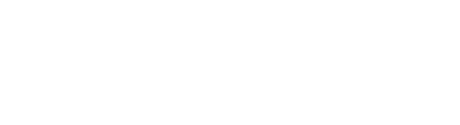

Rama m=(0,0) (x,y)=(1,1) -> Amplitud: 1.000-0.414j, Probabilidad: 1.172
Evaluando rama de medida: m0=0, m1=1. Variables clásicas (x,y)=(1, 1)
i1


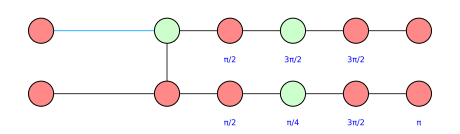

i2


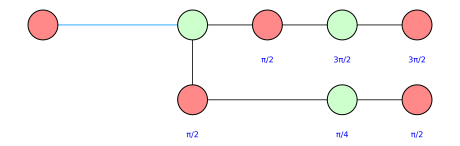

i8


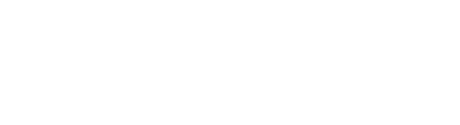

Rama m=(0,1) (x,y)=(1,1) -> Amplitud: 2.414-1.000j, Probabilidad: 6.828
Evaluando rama de medida: m0=1, m1=0. Variables clásicas (x,y)=(1, 1)
i1


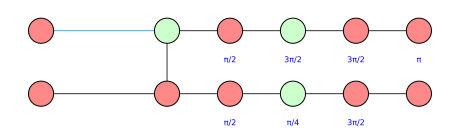

i2


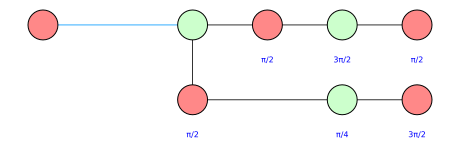

i8


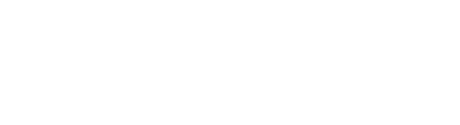

Rama m=(1,0) (x,y)=(1,1) -> Amplitud: -2.414+1.000j, Probabilidad: 6.828
Evaluando rama de medida: m0=1, m1=1. Variables clásicas (x,y)=(1, 1)
i1


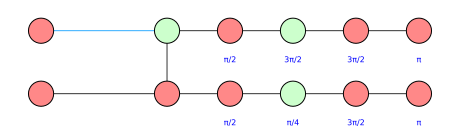

i2


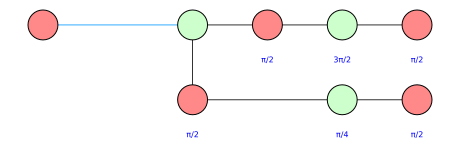

i8


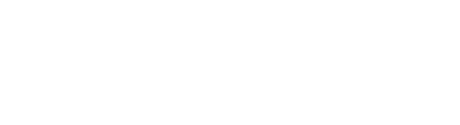

Rama m=(1,1) (x,y)=(1,1) -> Amplitud: 1.000-0.414j, Probabilidad: 1.172


In [16]:
from pyzx.simplify import *
resultados_medida = [(0, 0), (0, 1), (1, 0), (1, 1)]
variables_clasicas = [(0, 0), (0, 1), (1, 0), (1, 1)]
distribucion_chsh = {}

for x, y in variables_clasicas:
    distribucion_chsh[(x, y)] = {}

    for m0, m1 in resultados_medida:
        print(f"Evaluando rama de medida: m0={m0}, m1={m1}. Variables clásicas (x,y)=({x}, {y})")
        opt_graph = chsh_circuit(x, y).to_graph()

        entradas = opt_graph.inputs()
        salidas = opt_graph.outputs()

        opt_graph.set_type(entradas[1], zx.VertexType.X)
        opt_graph.set_type(entradas[0], zx.VertexType.X)
        opt_graph.set_type(salidas[0], zx.VertexType.X)
        opt_graph.set_phase(salidas[0], Fraction(m0, 1))
        opt_graph.set_type(salidas[1], zx.VertexType.X)
        opt_graph.set_phase(salidas[1], Fraction(m1, 1))

        while True:
            i1 = id_simp(opt_graph)
            if i1: 
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i1")
                    display(fig)
                    plt.close(fig)
            i2 = spider_simp(opt_graph)
            if i2:         
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i2")
                    display(fig)
                    plt.close(fig)
            i3 = pivot_simp(opt_graph)
            if i3:           
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i1")
                    display(fig)
                    plt.close(fig)
            if not (i1 or i2 or i3): break

        while True:
            i4 = lcomp_simp(opt_graph)
            if i4: 
                fig = zx.draw_matplotlib(opt_graph)
                print("i4")
                display(fig)
                plt.close(fig)
            i5 = pivot_boundary_simp(opt_graph)
            if i5: 
                fig = zx.draw_matplotlib(opt_graph)
                print("i5")
                display(fig)
                plt.close(fig)
            i6 = gadget_simp(opt_graph)
            if i6:
                fig = zx.draw_matplotlib(opt_graph)
                print("i6")
                display(fig)
                plt.close(fig)
            i7 = pivot_gadget_simp(opt_graph)
            if i7:
                fig = zx.draw_matplotlib(opt_graph)
                print("i7")
                display(fig)
                plt.close(fig)
            
            i8 = clifford_simp(opt_graph)
            if i8:
                fig = zx.draw_matplotlib(opt_graph)
                print("i8")
                display(fig)
                plt.close(fig)
            if not (i4 or i5 or i6 or i7 or i8): break
        amplitud = opt_graph.scalar.to_number()
        probabilidad = np.abs(amplitud)**2
        distribucion_chsh[(x, y)][(m0, m1)] = probabilidad
        
        print(f"Rama m=({m0},{m1}) (x,y)=({x},{y}) -> Amplitud: {amplitud:.3f}, Probabilidad: {probabilidad:.3f}")


In [17]:
probabilidad_victoria_total = 0

print("\n--- Resultados Analíticos Normalizados ---")
for x, y in variables_clasicas:
    # 1. Obtener la constante de normalización N_{x,y} (Traza total de la rama)
    suma_probabilidades = sum(distribucion_chsh[(x, y)].values())
    
    prob_victoria_xy = 0
    for (m0, m1), prob_bruta in distribucion_chsh[(x, y)].items():
        # 2. Normalización de la probabilidad marginal
        prob_norm = prob_bruta / suma_probabilidades
        
        # 3. Evaluación de la condición de victoria CHSH: a ⊕ b = x · y
        # En Python, el XOR lógico es != y el AND lógico es &
        if (m0 != m1) == (x & y):
            prob_victoria_xy += prob_norm
            
    print(f"Prob. Victoria para (x={x}, y={y}): {prob_victoria_xy * 100:.2f}%")
    
    # Promediamos sobre las 4 posibles elecciones uniformes de (x,y)
    probabilidad_victoria_total += prob_victoria_xy / 4

print(f"\n==================================================")
print(f"Probabilidad Analítica Exacta de Victoria: {probabilidad_victoria_total * 100:.2f}%")
print(f"Cota de Tsirelson Teórica: {((2 + np.sqrt(2))/4) * 100:.2f}%")
print(f"==================================================")


--- Resultados Analíticos Normalizados ---
Prob. Victoria para (x=0, y=0): 85.36%
Prob. Victoria para (x=0, y=1): 85.36%
Prob. Victoria para (x=1, y=0): 85.36%
Prob. Victoria para (x=1, y=1): 85.36%

Probabilidad Analítica Exacta de Victoria: 85.36%
Cota de Tsirelson Teórica: 85.36%


Simplificando el circuito para (x,y) = (0, 0)
i1


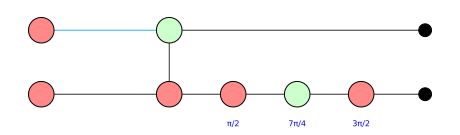

i2


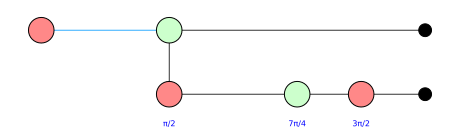

i8


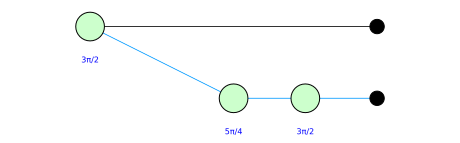

Simplificando el circuito para (x,y) = (0, 1)
i1


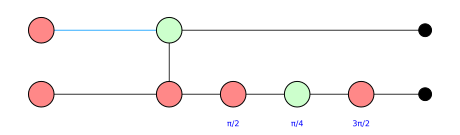

i2


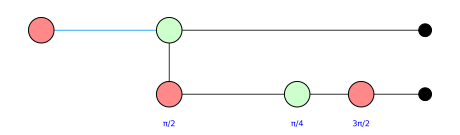

i8


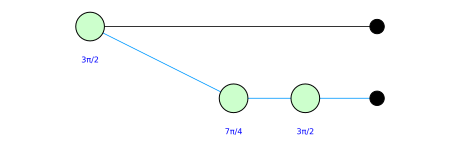

Simplificando el circuito para (x,y) = (1, 0)
i1


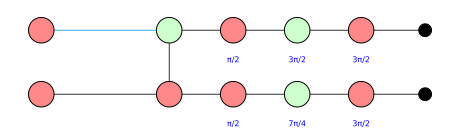

i2


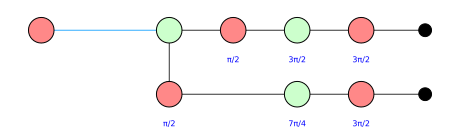

i8


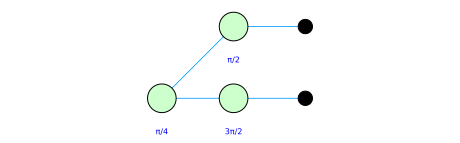

Simplificando el circuito para (x,y) = (1, 1)
i1


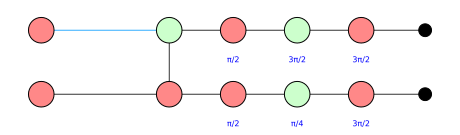

i2


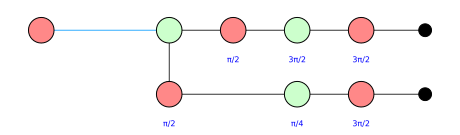

i8


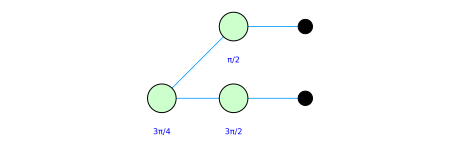

In [19]:
for x, y in variables_clasicas:
    opt_graph = chsh_circuit(x, y).to_graph()
    print(f"Simplificando el circuito para (x,y) = ({x}, {y})")

    entradas = opt_graph.inputs()

    opt_graph.set_type(entradas[1], zx.VertexType.X)
    opt_graph.set_type(entradas[0], zx.VertexType.X)

    while True:
        i1 = id_simp(opt_graph)
        if i1: 
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i1")
                    display(fig)
                    plt.close(fig)
        i2 = spider_simp(opt_graph)
        if i2:         
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i2")
                    display(fig)
                    plt.close(fig)
        i3 = pivot_simp(opt_graph)
        if i3:           
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i1")
                    display(fig)
                    plt.close(fig)
        if not (i1 or i2 or i3): break

    while True:
        i4 = lcomp_simp(opt_graph)
        if i4: 
                fig = zx.draw_matplotlib(opt_graph)
                print("i4")
                display(fig)
                plt.close(fig)
        i5 = pivot_boundary_simp(opt_graph)
        if i5: 
                fig = zx.draw_matplotlib(opt_graph)
                print("i5")
                display(fig)
                plt.close(fig)
        i6 = gadget_simp(opt_graph)
        if i6:
                fig = zx.draw_matplotlib(opt_graph)
                print("i6")
                display(fig)
                plt.close(fig)
        i7 = pivot_gadget_simp(opt_graph)
        if i7:
                fig = zx.draw_matplotlib(opt_graph)
                print("i7")
                display(fig)
                plt.close(fig)
            
        i8 = clifford_simp(opt_graph)
        if i8:
                fig = zx.draw_matplotlib(opt_graph)
                print("i8")
                display(fig)
                plt.close(fig)
        if not (i4 or i5 or i6 or i7 or i8): break
        

Definimos la estrategia cuántica. Como PyZX no tiene simulador probabilístico, extraemos el vector de estado del circuito y calculamos las probabilidades de cada estado

In [6]:
import numpy as np

def quantum_strategy(x, y):
    # 1. Generamos el circuito para las entradas x, y
    circ = chsh_circuit(x, y)
    
    matriz = circ.to_matrix()
    
    # Extraemos la primera columna (el estado asumiendo que empezamos en |00>)
    statevector = matriz[:, 0]
    
    # 3. Calculamos las probabilidades
    probabilidades = np.abs(statevector)**2
    
    # Aplanamos el array a una lista normal de Python por pura seguridad
    probabilidades = probabilidades.flatten().tolist()
    
    # 4. Simulamos un solo disparo (shots=1) basado en las probabilidades
    estados_posibles = ['00', '01', '10', '11']
    resultado_simulado = random.choices(estados_posibles, weights=probabilidades, k=1)[0]
    
    # 5. Extraemos los bits individuales para Alice (a) y Bob (b)
    a, b = int(resultado_simulado[0]), int(resultado_simulado[1])
    
    return a, b

Ejecutamos un bucle del juego para ver las victorias de la estrategia cuántica

In [7]:
NUM_GAMES = 1000
victorias = 0

for _ in range(NUM_GAMES):
    victorias += chsh_game(quantum_strategy)

tasa_victoria = victorias / NUM_GAMES
print(f"Tasa de victoria cuántica: {tasa_victoria * 100}%")

Tasa de victoria cuántica: 86.5%
